Importowanie bibliotek

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections.abc import Callable

Generowanie węzłów

In [2]:
def generate_uniform_nodes(n: int, interval: tuple[np.float64, np.float64], f: Callable[[np.float64], np.float64]) -> np.ndarray:
    xs = np.linspace(interval[0], interval[1], n)
    return np.array([(xs[i], f(xs[i])) for i in range(n)], dtype=np.float64)

def generate_chebyshev_nodes(n: int, interval: tuple[np.float64, np.float64], f: Callable[[np.float64], np.float64]) -> np.ndarray:
    a, b = interval[0], interval[1]
    n -= 2
    roots = [-1] + [np.cos((2*k - 1)/(2 * n) * np.pi) for k in range(1, n+1)] + [1]
    xs = [(a+b)/2 + (b-a)/2 * root for root in roots]
    return np.array([(xs[i], f(xs[i])) for i in range(n+2)], dtype=np.float64)

Generowanie funkcji obliczającej wartość wielomianu ze wzrou Lagrange'a

In [3]:
def lagrange_interpolation(nodes: np.ndarray, derivative_nodes: np.ndarray) -> Callable[[np.float64], np.float64]:
    n = len(nodes)
    xs = nodes[:, 0]
    ys = nodes[:, 1]

    def numerator(x, k):
        return np.prod([x - xs[i] for i in range(n) if i != k])
    def denominator(k):
        return np.prod([1/(xs[k] - xs[i]) for i in range(n) if i != k])
    denominators = np.array([denominator(k) for k in range(n)])

    return lambda x: np.float64(np.sum([ys[k] * numerator(x, k) * denominators[k] for k in range(n)]))

Generowanie funkcji obliczającej wartość wielomianu sposobem Hermite'a

In [4]:
def hermite_divided_difference_table(nodes: np.ndarray, deriv_nodes: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    n = len(nodes)
    nodes_x = nodes[:, 0]
    nodes_y = nodes[:, 1]
    nodes_derivative_y = deriv_nodes[:,1]
    z = np.zeros(2 * n, dtype=np.float64)
    dp = np.zeros((2 * n, 2 * n), dtype=np.float64)

    for i in range(n):
        z[2 * i] = nodes_x[i]
        z[2 * i + 1] = nodes_x[i]

    for i in range(n):
        dp[2 * i, 0] = nodes_y[i]
        dp[2 * i + 1, 0] = nodes_y[i]
        dp[2 * i + 1, 1] = nodes_derivative_y[i]
        if i != 0:
            dp[2 * i, 1] = (dp[2 * i, 0] - dp[2 * i - 1, 0]) / (z[2 * i] - z[2 * i - 1])

    for i in range(2, 2*n):
        for j in range(2, i+1):
            dp[i, j] = (dp[i,j -1] - dp[i-1, j-1])/(z[i] - z[i-j])

    return (z, dp)


def hermite_interpolation(nodes: np.ndarray, deriv_nodes: np.ndarray) -> Callable[[float], float]:
    
    nodes_x, dp = hermite_divided_difference_table(nodes, deriv_nodes)
    
    def interpolation(x: float) -> float:      
        n = len(nodes_x)
        result = dp[n - 1, n - 1]
        for i in range(n - 2, -1, -1):
            result = result * (x - nodes_x[i]) + dp[i, i]
        return result
    
    return interpolation

Benchmark algorytmów

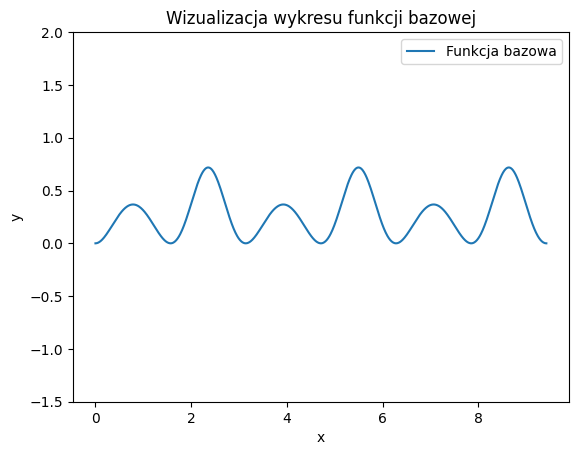

In [5]:
def prepare_function(k, m) -> Callable:
    return lambda x: np.pow(np.e, -k * np.sin(m*x)) + k * np.sin(m*x) - 1

def prepare_derivative(k, m) -> Callable:
    return lambda x: k * m * np.cos(m*x) - k * m * np.cos(m * x) * np.pow(np.e, -k * np.sin(m*x))

function = prepare_function(k=1, m=2)
derivative = prepare_derivative(k=1, m=2)

interval = (np.float64(0), np.float64(3*np.pi))
y_lim = (-1.5, 2)

xs = np.linspace(interval[0], interval[1], 1000)
ys = [function(x) for x in xs]
plt.ylim(y_lim)
plt.xlabel('x')
plt.ylabel('y')
plt.title("Wizualizacja wykresu funkcji bazowej")
plt.plot(xs, ys, label="Funkcja bazowa")
plt.legend()
plt.show()

Obliczenie błedów interpolacji wraz z zapisem do pliku "error_data.csv"

In [6]:
def benchmark(
    interval: tuple[np.float64, np.float64],
    polynomial: Callable,
    function: Callable,
    nodes,
    y_lim = None,
    polynomial_label: str = "",
    nodes_label: str = "",
    plot: bool = False
) -> tuple[np.float64, np.float64]:
    xs = np.linspace(interval[0], interval[1], 1000)

    polynomial_ys = np.array([polynomial(x) for x in xs])
    function_ys = np.array([function(x) for x in xs])

    max_error = np.max(np.abs(function_ys - polynomial_ys))
    root_mean_squared_error = np.sqrt(np.sum((function_ys - polynomial_ys) ** 2) / len(xs))

    if plot:
        plt.scatter(nodes[:, 0], nodes[:, 1], color='purple', label=nodes_label)
        plt.plot(xs, function_ys, label="Funkcja bazowa")
        plt.plot(xs, polynomial_ys, label=polynomial_label)

        if y_lim:
            plt.ylim(y_lim)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend()

    return (max_error, root_mean_squared_error)
    
    

In [7]:
ns = [i for i in range(2, 101)]
interpolations = [hermite_interpolation]
file_name = "error_data.csv"

error_data_df = pd.DataFrame(columns=["n", "Nodes","Interpolation", "Max Error", "Root Mean Squared Error"])

for n in ns:
    for interpolation in interpolations:
        uniform_nodes = generate_uniform_nodes(n, interval, function)
        uniform_derivative_nodes = generate_uniform_nodes(n, interval, derivative)
        max_error, root_mean_squared_error = benchmark(interval, interpolation(uniform_nodes, uniform_derivative_nodes), function, uniform_nodes)
        error_data_df.loc[len(error_data_df)] = {
            "n": n,
            "Nodes": "uniform_nodes",
            "Interpolation": interpolation.__name__,
            "Max Error": max_error,
            "Root Mean Squared Error": root_mean_squared_error,
        }

        chebyshev_nodes = generate_chebyshev_nodes(n, interval, function)
        chebyshev_derivative_nodes = generate_chebyshev_nodes(n, interval, derivative)
        max_error, root_mean_squared_error = benchmark(interval, interpolation(chebyshev_nodes, uniform_derivative_nodes), function, chebyshev_nodes)
        error_data_df.loc[len(error_data_df)] = {
            "n": n,
            "Nodes": "chebyshev_nodes",
            "Interpolation": interpolation.__name__,
            "Max Error": max_error,
            "Root Mean Squared Error": root_mean_squared_error,
        }

error_data_df.to_csv(file_name, index=False)

Wizualizacja błędów wraz z zapisem do plików w lokalizacji `plots/`

In [8]:
def plot_error_data(file_name, df, title, base_filter, log_scale=False):
    hermite_df   = df[(df["Interpolation"] == "hermite_interpolation") & base_filter]

    ax = hermite_df.plot(
        x="n",
        y="Max Error",
        label="Hermite - Max Error",
        color="green"
    )
    hermite_df.plot(
        x="n",
        y="Root Mean Squared Error",
        label="Hermite - RMSE",
        color="red",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel('Liczba węzłów')
    if log_scale:
        ax.set_yscale("log")

    plt.legend()
    plt.savefig(file_name)
    plt.close()

In [9]:
file_name = "error_data.csv"
directory = "plots/error/"

if not os.path.exists(directory):
    os.makedirs(directory)

df = pd.read_csv(file_name)

base_filter = (df["Nodes"] == "uniform_nodes") & (df["n"] <= 100)
plot_error_data("plots/error/uniform_long", df, "Wizualizacja błędów interpolacji dla równoodległych węzłów", base_filter)
plot_error_data("plots/error/uniform_long_log", df, "Wizualizacja błędów interpolacji dla równoodległych węzłów\nw skali logarytmicznej", base_filter, log_scale=True)

base_filter = (df["Nodes"] == "uniform_nodes") & (df["n"] <= 25)
plot_error_data("plots/error/uniform_short", df, "Wizualizacja błędów interpolacji dla równoodległych węzłów", base_filter)
plot_error_data("plots/error/uniform_short_log", df, "Wizualizacja błędów interpolacji dla równoodległych węzłów\nw skali logarytmicznej", base_filter, log_scale=True)

base_filter = (df["Nodes"] == "chebyshev_nodes") & (df["n"] <= 100)
plot_error_data("plots/error/chebyshev_long", df, "Wizualizacja błędów interpolacji dla węzłów Czebyszewa", base_filter)
plot_error_data("plots/error/chebyshev_long_log", df, "Wizualizacja błędów interpolacji dla węzłów Czebyszewa\nw skali logarytmicznej", base_filter, log_scale=True)

base_filter = (df["Nodes"] == "chebyshev_nodes") & (df["n"] <= 25)
plot_error_data("plots/error/chebyshev_short", df, "Wizualizacja błędów interpolacji dla węzłów Czebyszewa", base_filter)
plot_error_data("plots/error/chebyshev_short_log", df, "Wizualizacja błędów interpolacji dla węzłów Czebyszewa\nw skali logarytmicznej", base_filter, log_scale=True)


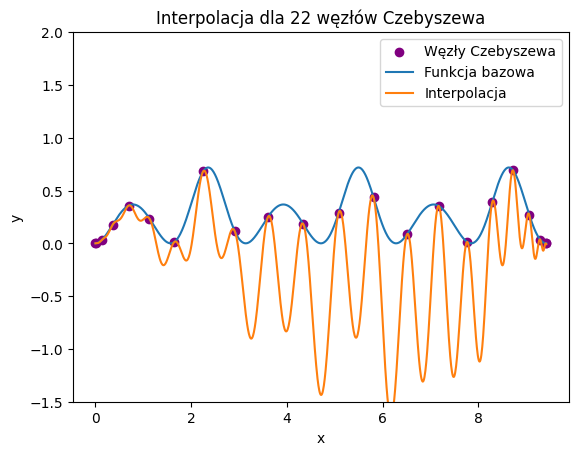

In [10]:
ns = [3, 4, 6, 7, 19, 22]
directories = ["plots/uniform", "plots/chebyshev"]


for directory in directories:   
    if not os.path.exists(directory):
        os.makedirs(directory)

for n in ns:
    uniform_nodes = generate_uniform_nodes(n, interval, function)
    uniform_derivative_nodes = generate_uniform_nodes(n, interval, derivative)
    chebyshev_nodes = generate_chebyshev_nodes(n, interval, function)
    chebyshev_derivative_nodes = generate_chebyshev_nodes(n, interval, derivative)
    
    plt.clf()
    benchmark(interval, hermite_interpolation(uniform_nodes, uniform_derivative_nodes), function, uniform_nodes, polynomial_label="Interpolacja", nodes_label="Równoodległe węzły", y_lim=y_lim, plot=True)
    plt.title(f"Interpolacja dla {n} równoodległych węzłów")
    plt.savefig(f"{directories[0]}/hermite_{n}")

    plt.clf()
    benchmark(interval, hermite_interpolation(chebyshev_nodes, chebyshev_derivative_nodes), function, chebyshev_nodes, polynomial_label="Interpolacja", nodes_label="Węzły Czebyszewa", y_lim=y_lim, plot=True)
    plt.title(f"Interpolacja dla {n} węzłów Czebyszewa")
    plt.savefig(f"{directories[1]}/hermite_{n}")

    